# Comparacion de Random Forest, XGBoost, LSTM y Transformer

Lee los archivos `metricas.json` y `predicciones_test.csv` generados por los cuatro notebooks. No entrena modelos.

## Regla de interpretacion

Random Forest y XGBoost trabajan con **transacciones**; LSTM y Transformer trabajan con **secuencias**. El notebook presenta ambos resultados, pero marca esta diferencia. Una clasificacion global del “mejor modelo” solo es metodologicamente valida si los cuatro predicen exactamente el mismo evento, usan las mismas etiquetas y representan la misma poblacion de prueba.


## 1. Importaciones y rutas

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import seaborn as sns
ROOT=Path('.')
MODEL_DIRS={
 'Random Forest':ROOT/'resultados_random_forest_paysim',
 'XGBoost':ROOT/'resultados_xgboost_paysim',
 'LSTM':ROOT/'resultados_lstm_paysim',
 'Transformer':ROOT/'resultados_transformer_paysim'}
OUTPUT_DIR=Path('comparacion_modelos_paysim'); OUTPUT_DIR.mkdir(exist_ok=True)


## 2. Cargar y validar resultados

In [2]:
rows=[]; predictions={}
for name,d in MODEL_DIRS.items():
    mp=d/'metricas.json'; pp=d/'predicciones_test.csv'
    if not mp.exists(): raise FileNotFoundError(f'Falta {mp}. Ejecuta primero el notebook de {name}.')
    meta=json.load(open(mp,encoding='utf-8'))
    for policy,key in [('0.5','metrics_threshold_0_5'),('validacion','metrics_threshold_validation')]:
        row={'model':name,'threshold_policy':policy,'data_unit':meta.get('data_unit'),
             'split_mode':meta.get('split_mode'),'n_test':meta.get('n_test'),
             'training_seconds':meta.get('training_seconds'),'inference_seconds':meta.get('inference_seconds')}
        row.update(meta[key]); rows.append(row)
    if pp.exists(): predictions[name]=pd.read_csv(pp)
results=pd.DataFrame(rows)
display(results)
results.to_csv(OUTPUT_DIR/'comparacion_metricas_completa.csv',index=False)
# Validacion de comparabilidad por unidad y numero de casos.
summary=results[results.threshold_policy=='validacion']
print('Unidades:',summary.groupby('data_unit')['model'].apply(list).to_dict())
if summary.data_unit.nunique()>1:
    print('ADVERTENCIA: hay unidades distintas; no declares un ganador global sin alinear el objetivo.')


,model,threshold_policy,data_unit,split_mode,n_test,training_seconds,inference_seconds,threshold,roc_auc,pr_auc,precision,recall,f1,tn,fp,fn,tp
0,Random Forest,0.5,transaccion,time,1272524,559.249879,9.207002,0.500000,0.861237,0.144354,0.351194,0.383639,0.366700,1265255,3015,2622,1632
1,Random Forest,validacion,transaccion,time,1272524,559.249879,9.207002,0.557956,0.861237,0.144354,0.347846,0.362482,0.355013,1265379,2891,2712,1542
2,XGBoost,0.5,transaccion,time,1272524,20.820940,0.180462,0.500000,0.945974,0.278704,0.021915,0.872120,0.042756,1102690,165580,544,3710
3,XGBoost,validacion,transaccion,time,1272524,20.820940,0.180462,0.547810,0.945974,0.278704,0.345568,0.378467,0.361270,1265221,3049,2644,1610
4,LSTM,0.5,secuencia,time,1272524,NaN,56.788777,0.500000,0.998889,0.960030,0.717460,0.960534,0.821391,1270254,623,65,1582
5,LSTM,validacion,secuencia,time,1272524,NaN,56.788777,0.679762,0.998889,0.960030,0.873322,0.908318,0.890476,1270660,217,151,1496
6,Transformer,0.5,secuencia,time,1272524,NaN,33.714220,0.500000,0.997630,0.939658,0.802476,0.905282,0.850785,1270510,367,156,1491
7,Transformer,validacion,secuencia,time,1272524,NaN,33.714220,0.790429,0.997630,0.939658,0.938305,0.840316,0.886611,1270786,91,263,1384


Unidades: {'secuencia': ['LSTM', 'Transformer'], 'transaccion': ['Random Forest', 'XGBoost']}
ADVERTENCIA: hay unidades distintas; no declares un ganador global sin alinear el objetivo.


## 3. Tabla principal con umbral elegido en validacion

In [4]:
# Seleccionar resultados con el umbral elegido en validación
# y conservar únicamente Random Forest y XGBoost
modelos_tabulares = ["Random Forest", "XGBoost"]

main = (
    results[
        (results["threshold_policy"] == "validacion") &
        (results["model"].isin(modelos_tabulares))
    ]
    .set_index("model")
)

# Columnas que se mostrarán
cols = [
    "data_unit",
    "roc_auc",
    "pr_auc",
    "precision",
    "recall",
    "f1",
    "fp",
    "fn",
    "threshold",
    "training_seconds",
    "inference_seconds"
]

# Ordenar de mayor a menor según PR-AUC
tabla_principal = (
    main[cols]
    .sort_values("pr_auc", ascending=False)
)

# Mostrar tabla
display(tabla_principal)

# Guardar resultados
tabla_principal.to_csv(
    OUTPUT_DIR / "tabla_principal_random_forest_xgboost.csv",
    encoding="utf-8-sig"
)

,data_unit,roc_auc,pr_auc,precision,recall,f1,fp,fn,threshold,training_seconds,inference_seconds
model,,,,,,,,,,,
XGBoost,transaccion,0.945974,0.278704,0.345568,0.378467,0.361270,3049,2644,0.547810,20.820940,0.180462
Random Forest,transaccion,0.861237,0.144354,0.347846,0.362482,0.355013,2891,2712,0.557956,559.249879,9.207002


In [3]:
main=results[results.threshold_policy=='validacion'].set_index('model')
cols=['data_unit','roc_auc','pr_auc','precision','recall','f1','fp','fn','threshold','training_seconds','inference_seconds']
display(main[cols].sort_values('pr_auc',ascending=False))
main[cols].to_csv(OUTPUT_DIR/'tabla_principal.csv')


,data_unit,roc_auc,pr_auc,precision,recall,f1,fp,fn,threshold,training_seconds,inference_seconds
model,,,,,,,,,,,
LSTM,secuencia,0.998889,0.960030,0.873322,0.908318,0.890476,217,151,0.679762,NaN,56.788777
Transformer,secuencia,0.997630,0.939658,0.938305,0.840316,0.886611,91,263,0.790429,NaN,33.714220
XGBoost,transaccion,0.945974,0.278704,0.345568,0.378467,0.361270,3049,2644,0.547810,20.820940,0.180462
Random Forest,transaccion,0.861237,0.144354,0.347846,0.362482,0.355013,2891,2712,0.557956,559.249879,9.207002


## 4. Graficas comparativas

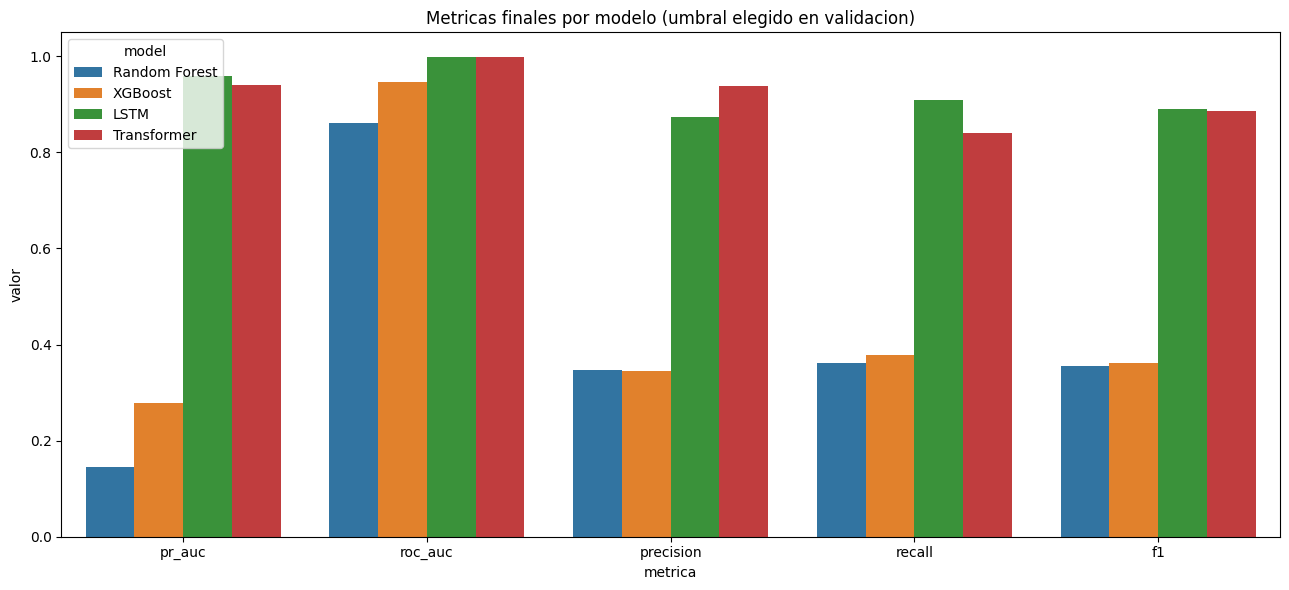

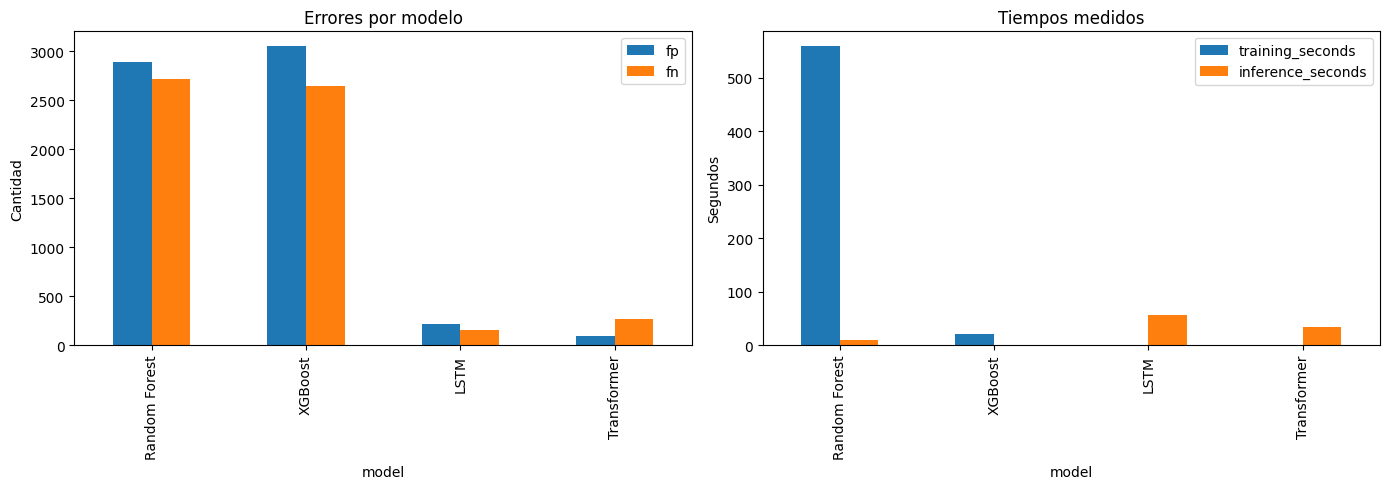

In [4]:
metric_cols=['pr_auc','roc_auc','precision','recall','f1']
plot_df=main[metric_cols].reset_index().melt('model',var_name='metrica',value_name='valor')
plt.figure(figsize=(13,6)); sns.barplot(data=plot_df,x='metrica',y='valor',hue='model')
plt.ylim(0,1.05); plt.title('Metricas finales por modelo (umbral elegido en validacion)'); plt.tight_layout()
plt.savefig(OUTPUT_DIR/'comparacion_metricas.png',dpi=300,bbox_inches='tight'); plt.show()
fig,ax=plt.subplots(1,2,figsize=(14,5))
main[['fp','fn']].plot(kind='bar',ax=ax[0]); ax[0].set_title('Errores por modelo'); ax[0].set_ylabel('Cantidad')
main[['training_seconds','inference_seconds']].plot(kind='bar',ax=ax[1]); ax[1].set_title('Tiempos medidos'); ax[1].set_ylabel('Segundos')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'comparacion_errores_tiempos.png',dpi=300,bbox_inches='tight'); plt.show()


## 5. Comparacion por familias comparables

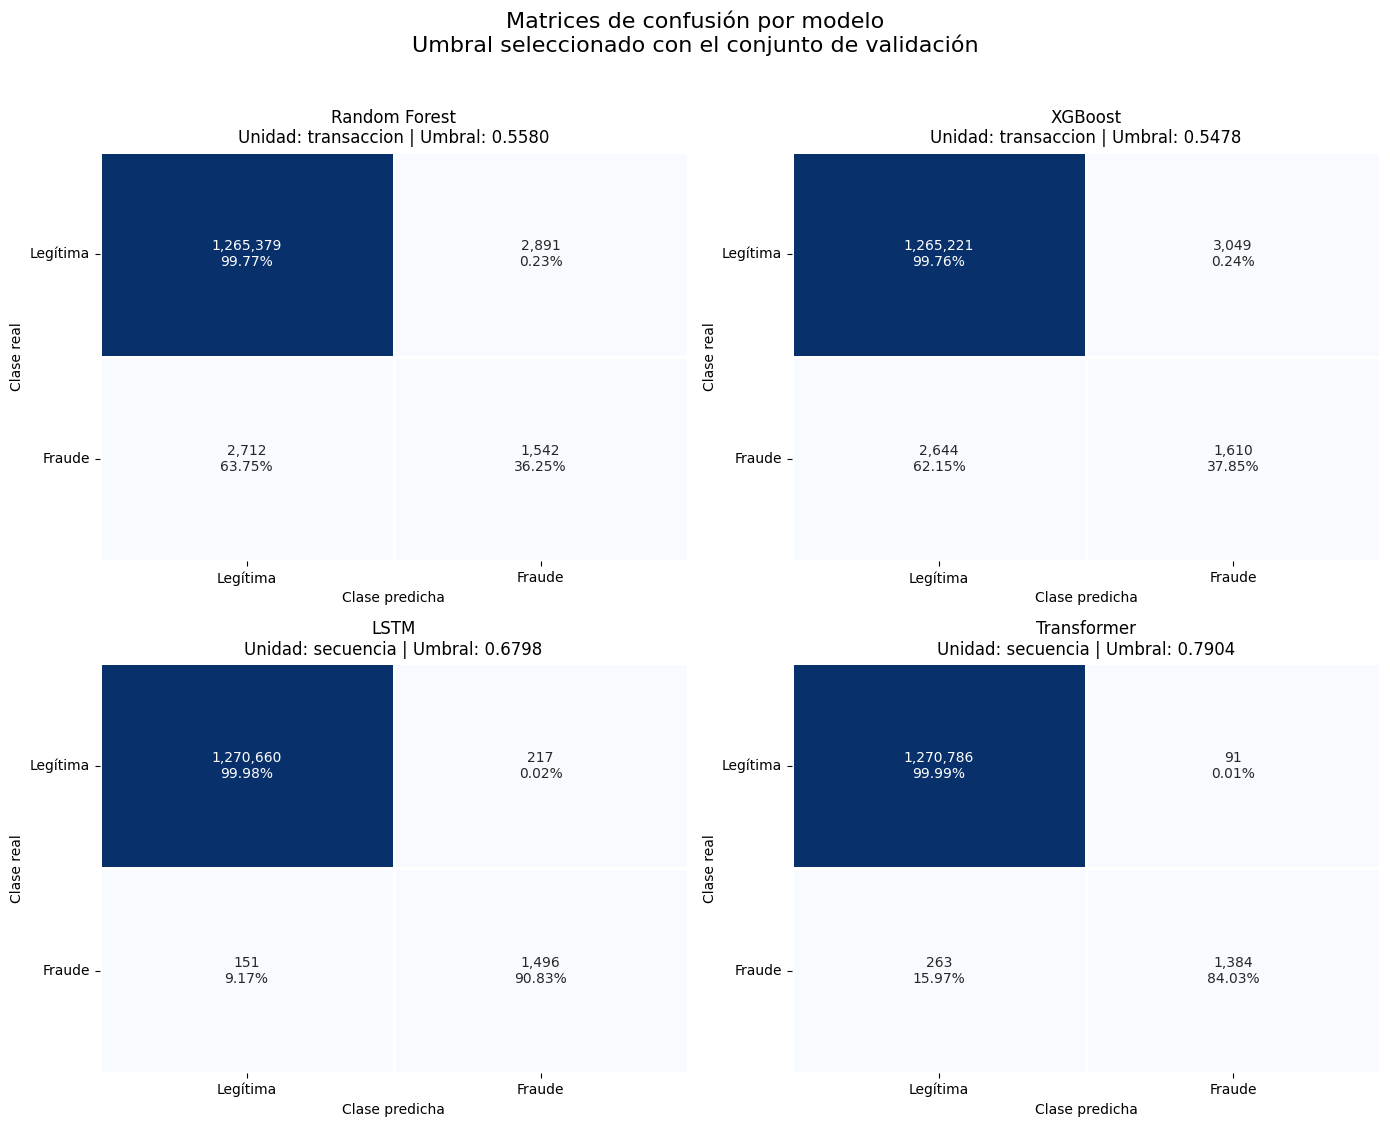

Imagen guardada en: comparacion_modelos_paysim\matrices_confusion_4_modelos.png


In [10]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Orden deseado de los modelos
model_order = [
    "Random Forest",
    "XGBoost",
    "LSTM",
    "Transformer"
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 11)
)

axes = axes.flatten()

for ax, model_name in zip(axes, model_order):

    row = main.loc[model_name]

    cm = np.array([
        [int(row["tn"]), int(row["fp"])],
        [int(row["fn"]), int(row["tp"])]
    ])

    # Anotaciones con cantidad y porcentaje por clase real
    row_totals = cm.sum(axis=1, keepdims=True)
    percentages = np.divide(
        cm,
        row_totals,
        out=np.zeros_like(cm, dtype=float),
        where=row_totals != 0
    )

    annotations = np.empty_like(cm, dtype=object)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annotations[i, j] = (
                f"{cm[i, j]:,}\n"
                f"{percentages[i, j]:.2%}"
            )

    sns.heatmap(
        cm,
        annot=annotations,
        fmt="",
        cmap="Blues",
        cbar=False,
        linewidths=1,
        linecolor="white",
        ax=ax
    )

    ax.set_title(
        f"{model_name}\n"
        f"Unidad: {row['data_unit']} | "
        f"Umbral: {row['threshold']:.4f}",
        fontsize=12
    )

    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")

    ax.set_xticklabels(
        ["Legítima", "Fraude"],
        rotation=0
    )

    ax.set_yticklabels(
        ["Legítima", "Fraude"],
        rotation=0
    )

fig.suptitle(
    "Matrices de confusión por modelo\n"
    "Umbral seleccionado con el conjunto de validación",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

matrix_path = OUTPUT_DIR / "matrices_confusion_4_modelos.png"

plt.savefig(
    matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Imagen guardada en:", matrix_path)

In [5]:
for unit,g in main.groupby('data_unit'):
    print('\nUnidad:',unit)
    display(g[['pr_auc','roc_auc','precision','recall','f1','fp','fn']].sort_values('pr_auc',ascending=False))



Unidad: secuencia


,pr_auc,roc_auc,precision,recall,f1,fp,fn
model,,,,,,,
LSTM,0.960030,0.998889,0.873322,0.908318,0.890476,217,151
Transformer,0.939658,0.997630,0.938305,0.840316,0.886611,91,263



Unidad: transaccion


,pr_auc,roc_auc,precision,recall,f1,fp,fn
model,,,,,,,
XGBoost,0.278704,0.945974,0.345568,0.378467,0.361270,3049,2644
Random Forest,0.144354,0.861237,0.347846,0.362482,0.355013,2891,2712


In [8]:
## Interpretación de las métricas de evaluación

En este estudio, la clase positiva corresponde a las transacciones
fraudulentas (`isFraud = 1`), mientras que la clase negativa corresponde
a las transacciones legítimas (`isFraud = 0`).

Las métricas presentadas se interpretan de la siguiente manera:

- **ROC-AUC:** mide la capacidad general del modelo para asignar puntuaciones
  superiores a las operaciones fraudulentas en comparación con las legítimas.
  Un valor cercano a 1 indica una elevada capacidad de discriminación.
  Debido al fuerte desbalance del conjunto PaySim, esta métrica se interpreta
  conjuntamente con PR-AUC.

- **PR-AUC:** resume el comportamiento de la relación entre precision y recall
  a través de diferentes umbrales. Es especialmente relevante en este estudio,
  debido a que las transacciones fraudulentas representan una clase minoritaria.

- **Precision:** indica qué proporción de las transacciones clasificadas como
  fraudulentas correspondió realmente a fraude. Una precision elevada representa
  una menor proporción de falsas alertas.

  \[
  Precision = \frac{TP}{TP + FP}
  \]

- **Recall o sensibilidad:** representa la proporción de fraudes reales que fueron
  detectados por el modelo. Un recall elevado indica que pocos fraudes pasaron
  inadvertidos.

  \[
  Recall = \frac{TP}{TP + FN}
  \]

- **F1:** corresponde a la media armónica entre precision y recall. Esta métrica
  alcanza valores elevados cuando el modelo mantiene un equilibrio favorable
  entre la detección de fraudes y la reducción de falsas alertas.

  \[
  F1 = 2 \times
  \frac{Precision \times Recall}{Precision + Recall}
  \]

- **Falsos positivos (FP):** transacciones legítimas clasificadas incorrectamente
  como fraudulentas. Estos errores pueden representar alertas, investigaciones
  o bloqueos innecesarios.

- **Falsos negativos (FN):** transacciones fraudulentas clasificadas incorrectamente
  como legítimas. Estos casos representan fraudes que el modelo no consiguió detectar.

- **Threshold:** umbral utilizado para transformar la probabilidad estimada por
  el modelo en una clasificación binaria. Por ejemplo, con un umbral de 0.60,
  una observación se clasifica como fraude cuando su probabilidad estimada es
  igual o superior a 0.60.

- **Training seconds:** tiempo empleado exclusivamente en el ajuste o entrenamiento
  del modelo, expresado en segundos.

- **Inference seconds:** tiempo empleado para generar las predicciones del conjunto
  de prueba, expresado en segundos.

- **Data unit:** unidad de observación procesada por el modelo. Random Forest y
  XGBoost trabajan con transacciones individuales, mientras que LSTM y Transformer
  trabajan con secuencias de transacciones.

### Estructura de la matriz de confusión

|                         | Predicción legítima | Predicción fraude |
|-------------------------|---------------------:|------------------:|
| **Real legítima**       | TN                   | FP                |
| **Real fraude**         | FN                   | TP                |

Donde:

- **TN:** transacciones legítimas correctamente clasificadas.
- **FP:** transacciones legítimas clasificadas como fraude.
- **FN:** fraudes que no fueron detectados.
- **TP:** fraudes correctamente detectados.

> Los valores de FP y FN solamente son directamente comparables cuando los
> modelos fueron evaluados sobre las mismas observaciones y etiquetas. En este
> análisis, Random Forest y XGBoost comparten el mismo conjunto de prueba.
> LSTM y Transformer también comparten el mismo conjunto de prueba dentro de
> la familia secuencial. No obstante, las unidades `transaccion` y `secuencia`
> deben analizarse por separado.

SyntaxError: invalid syntax (2587478429.py, line 3)

In [9]:
## Resumen de los resultados comparativos

Los resultados se analizaron utilizando el umbral seleccionado con el conjunto
de validación. La comparación se realizó por familias de modelos debido a que
Random Forest y XGBoost procesan transacciones individuales, mientras que LSTM
y Transformer procesan secuencias.

### Modelos basados en transacciones

Entre los modelos tabulares, XGBoost registró el mejor desempeño general.
Obtuvo una PR-AUC de 0.2787 y una ROC-AUC de 0.9460, mientras que Random Forest
alcanzó una PR-AUC de 0.1444 y una ROC-AUC de 0.8612.

Con el umbral seleccionado en validación, XGBoost alcanzó una precision de
0.3456, un recall de 0.3785 y una puntuación F1 de 0.3613. Random Forest obtuvo
una precision de 0.3478, un recall de 0.3625 y una puntuación F1 de 0.3550.

Aunque Random Forest presentó ligeramente menos falsos positivos —2,891 frente
a 3,049 de XGBoost—, XGBoost produjo menos falsos negativos —2,644 frente a
2,712— y presentó mejores valores de PR-AUC, ROC-AUC, recall y F1.

XGBoost también registró un menor tiempo computacional: su entrenamiento requirió
aproximadamente 20.82 segundos y su inferencia 0.18 segundos. Random Forest
necesitó aproximadamente 559.25 segundos para el entrenamiento y 9.21 segundos
para la inferencia.

Por lo tanto, dentro de los modelos basados en transacciones, XGBoost presentó
la mejor combinación entre capacidad predictiva, detección de fraudes y
eficiencia computacional.

### Modelos basados en secuencias

Dentro de los modelos secuenciales, LSTM obtuvo la mayor PR-AUC, con un valor
de 0.9600, y la mayor ROC-AUC, con 0.9989. El Transformer alcanzó una PR-AUC
de 0.9397 y una ROC-AUC de 0.9976.

LSTM obtuvo una precision de 0.8733, un recall de 0.9083 y una puntuación F1
de 0.8905. El Transformer presentó una precision superior, de 0.9383, pero
un recall inferior, de 0.8403, y una puntuación F1 de 0.8866.

LSTM detectó una mayor proporción de fraudes y produjo 151 falsos negativos,
mientras que el Transformer produjo 263. Sin embargo, el Transformer generó
menos falsas alertas, con 91 falsos positivos frente a los 217 de LSTM.

Estos resultados muestran un compromiso operacional: LSTM priorizó la detección
de fraudes y redujo los falsos negativos, mientras que el Transformer produjo
alertas más precisas y redujo los falsos positivos.

El Transformer presentó un menor tiempo de inferencia, con aproximadamente
33.71 segundos, mientras que LSTM requirió 56.79 segundos. Los tiempos de
entrenamiento de ambos modelos no fueron registrados en los archivos de métricas,
por lo que no se realizó una comparación de ese aspecto.

### Consideración metodológica

No se declaró un único modelo ganador entre los cuatro algoritmos, porque los
modelos tabulares y secuenciales utilizan representaciones de entrada distintas.
La comparación directa y metodológicamente válida se realizó dentro de cada
familia: Random Forest frente a XGBoost, y LSTM frente a Transformer.

SyntaxError: invalid character '—' (U+2014) (1746137671.py, line 18)

In [11]:
error_table = main[
    [
        "data_unit",
        "tn",
        "fp",
        "fn",
        "tp",
        "precision",
        "recall",
        "f1",
        "threshold"
    ]
].copy()

error_table["false_positive_rate"] = (
    error_table["fp"] /
    (error_table["fp"] + error_table["tn"])
)

error_table["false_negative_rate"] = (
    error_table["fn"] /
    (error_table["fn"] + error_table["tp"])
)

error_table["specificity"] = (
    error_table["tn"] /
    (error_table["tn"] + error_table["fp"])
)

error_table["fraudes_reales"] = (
    error_table["tp"] + error_table["fn"]
)

error_table["alertas_generadas"] = (
    error_table["tp"] + error_table["fp"]
)

columns = [
    "data_unit",
    "precision",
    "recall",
    "f1",
    "specificity",
    "false_positive_rate",
    "false_negative_rate",
    "fp",
    "fn",
    "fraudes_reales",
    "alertas_generadas",
    "threshold"
]

display(
    error_table[columns]
    .sort_values(
        ["data_unit", "f1"],
        ascending=[True, False]
    )
    .style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
        "specificity": "{:.4f}",
        "false_positive_rate": "{:.6%}",
        "false_negative_rate": "{:.4%}",
        "fp": "{:,.0f}",
        "fn": "{:,.0f}",
        "fraudes_reales": "{:,.0f}",
        "alertas_generadas": "{:,.0f}",
        "threshold": "{:.4f}"
    })
)

error_table[columns].to_csv(
    OUTPUT_DIR / "tabla_errores_completa.csv"
)

,data_unit,precision,recall,f1,specificity,false_positive_rate,false_negative_rate,fp,fn,fraudes_reales,alertas_generadas,threshold
model,,,,,,,,,,,,
LSTM,secuencia,0.8733,0.9083,0.8905,0.9998,0.017075%,9.1682%,217,151,"1,647","1,713",0.6798
Transformer,secuencia,0.9383,0.8403,0.8866,0.9999,0.007160%,15.9684%,91,263,"1,647","1,475",0.7904
XGBoost,transaccion,0.3456,0.3785,0.3613,0.9976,0.240406%,62.1533%,"3,049","2,644","4,254","4,659",0.5478
Random Forest,transaccion,0.3478,0.3625,0.3550,0.9977,0.227948%,63.7518%,"2,891","2,712","4,254","4,433",0.5580


## 6. Verificar que comparten exactamente el mismo test dentro de cada familia

In [6]:
def same_test(a,b):
    if a not in predictions or b not in predictions: return False,'Falta archivo de predicciones'
    pa,pb=predictions[a],predictions[b]
    if len(pa)!=len(pb): return False,'Distinto numero de casos'
    if not np.array_equal(pa['index_original'].to_numpy(),pb['index_original'].to_numpy()): return False,'Indices distintos'
    if not np.array_equal(pa['y_true'].to_numpy(),pb['y_true'].to_numpy()): return False,'Etiquetas distintas'
    return True,'Mismo conjunto y etiquetas'
for a,b in [('Random Forest','XGBoost'),('LSTM','Transformer')]: print(a,'vs',b,':',same_test(a,b))


Random Forest vs XGBoost : (True, 'Mismo conjunto y etiquetas')
LSTM vs Transformer : (True, 'Mismo conjunto y etiquetas')
